# Scoring the Youth Mental Health Map Dimensions

This notebook explains how to calculate scores for each of the four Youth Mental Health Map dimensions from raw questionnaire data using Python.

**Dimensions:**

1. Uncontrollable thinking patterns  
2. Re-experiencing difficult events  
3. Rigid high standards  
4. Emotional agency

The script assumes that you have item-level responses and demonstrates how to: 

- Compute scores for each dimension
- Plot scores to show distribution
  

Here we're using data from Smith et al (2025), which is available here.

### Load data

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset (replace with actual filename)
df = pd.read_csv("YMHM_data.csv")

# Subset YMHM item responses (replace with YMHM item names)
ymhm_df = df.loc[:,'YMHM_1':'YMHM_34']

# Preview
ymhm_df.head()


,YMHM_1,YMHM_2,YMHM_3,YMHM_4,YMHM_5,YMHM_6,YMHM_7,YMHM_8,YMHM_9,YMHM_10,...,YMHM_25,YMHM_26,YMHM_27,YMHM_28,YMHM_29,YMHM_30,YMHM_31,YMHM_32,YMHM_33,YMHM_34
0,2,1,3,2,2,3,1,3,5,4,...,2,1,1,2,2,4,2,3,2,3
1,2,1,2,2,1,1,1,3,4,3,...,4,2,2,4,2,2,2,4,5,1
2,2,1,1,2,2,1,1,2,4,2,...,2,2,2,4,3,3,3,4,2,3
3,2,3,3,3,2,4,2,4,4,4,...,2,2,2,3,4,3,4,3,2,1
4,4,2,4,4,4,1,1,2,5,5,...,4,3,3,3,1,2,1,2,1,2


In [47]:
# Load factor weights
factor_weights = pd.read_csv("YMHM_factor_weights.csv")

# Drop question column
factor_weights = factor_weights.iloc[:,1:]

# Preview
factor_weights.head()

,uncontrollable_thinking,re-experiencing,rigid_standards,emotional_agency
0,-0.022207,0.109453,0.017620,-0.039535
1,-0.090080,0.141296,-0.009809,0.007799
2,-0.043245,0.149855,-0.014777,-0.015292
3,0.003612,0.102355,-0.018548,-0.016248
4,-0.052179,0.139087,0.007134,0.029730



### Score data
Here, we multiply each item by its corresponding factor weight, sum the weighted item scores, and add the model intercept to produce the final factor scores for each dimension.

In [48]:
# Score data
scores = ymhm_df @ factor_weights.values[:-1] + factor_weights.values[-1]

# Preview
scores.head()

,0,1,2,3
0,0.682100,-0.444300,0.336687,-2.345224
1,-0.921573,0.005090,-0.006555,-1.704998
2,-2.098636,0.170183,-0.333048,-1.787755
3,0.333388,0.639599,-0.124354,-1.427377
4,0.431366,0.286065,1.148582,0.772588



### Plot scores
Next we plot the dimension distributions

In [49]:
# Add column names and IDs
scores.columns = ['uncontrollable_thinking', 're-experiencing', 'rigid_standards', 'emotional_agency']
scores.loc[:, 'id'] = df['id'].values

# Preview
scores.head()


,uncontrollable_thinking,re-experiencing,rigid_standards,emotional_agency,id
0,0.682100,-0.444300,0.336687,-2.345224,BE003DO
1,-0.921573,0.005090,-0.006555,-1.704998,TI901HO
2,-2.098636,0.170183,-0.333048,-1.787755,EL901MA
3,0.333388,0.639599,-0.124354,-1.427377,CH678HO
4,0.431366,0.286065,1.148582,0.772588,TE678AA


/var/folders/2v/b_wzr1yx0qsdb44hnynqmflr0000gn/T/ipykernel_92930/3453706550.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(scores[dim], ax=ax[n], color=col[n], hist_kws={'ec':col[n], 'alpha':0.5})
/var/folders/2v/b_wzr1yx0qsdb44hnynqmflr0000gn/T/ipykernel_92930/3453706550.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed297445

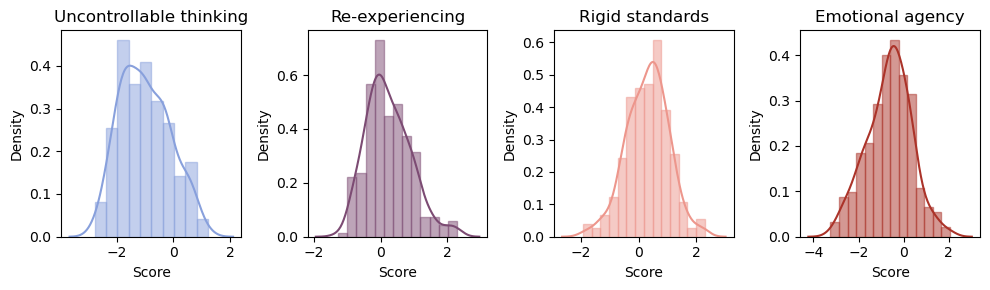

In [51]:
col =["#88a0dc","#7c4b73", "#ed968c", "#ab3329"] # colorblind friendly
dims = ['Uncontrollable thinking', 'Re-experiencing', 'Rigid standards', 'Emotional agency']

f, ax = plt.subplots(1, 4, figsize=(10, 3), dpi=100, facecolor='white')

for n, dim in enumerate(['uncontrollable_thinking', 're-experiencing', 'rigid_standards', 'emotional_agency']):
    sns.distplot(scores[dim], ax=ax[n], color=col[n], hist_kws={'ec':col[n], 'alpha':0.5})
    ax[n].set_xlabel('Score')
    if n == 0:
        ax[n].set_ylabel('Density')
    ax[n].set_title(dims[n], fontweight='light')
    
plt.tight_layout()
plt.savefig('../figures/YMHM_distributions.svg')

### Add scores to the original dataframe and save
Scores on the four YMHM dimensions can now be used for subsequent analyses

In [45]:
full_df = pd.merge(scores, df, on='id')
full_df.to_csv('../Data/full_df.csv')
full_df.head()

,uncontrollable_thinking,re-experiencing,rigid_standards,emotional_agency,id,YMHM_1,YMHM_2,YMHM_3,YMHM_4,YMHM_5,...,YMHM_25,YMHM_26,YMHM_27,YMHM_28,YMHM_29,YMHM_30,YMHM_31,YMHM_32,YMHM_33,YMHM_34
0,0.682100,-0.444300,0.336687,-2.345224,BE003DO,2,1,3,2,2,...,2,1,1,2,2,4,2,3,2,3
1,-0.921573,0.005090,-0.006555,-1.704998,TI901HO,2,1,2,2,1,...,4,2,2,4,2,2,2,4,5,1
2,-2.098636,0.170183,-0.333048,-1.787755,EL901MA,2,1,1,2,2,...,2,2,2,4,3,3,3,4,2,3
3,0.333388,0.639599,-0.124354,-1.427377,CH678HO,2,3,3,3,2,...,2,2,2,3,4,3,4,3,2,1
4,0.431366,0.286065,1.148582,0.772588,TE678AA,4,2,4,4,4,...,4,3,3,3,1,2,1,2,1,2
